In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap
import lime

from lime.lime_tabular import LimeTabularExplainer



In [2]:

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

In [3]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [4]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (24000, 23)
Testing Features  : (6000, 23)
Training Labels   : (24000,)
Testing Labels    : (6000,)


In [9]:
model = joblib.load("../models/logistic_regression.pkl")
print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [7]:
predictions = model.predict(X_test)

print(predictions[:10])

[0 0 0 0 0 0 0 0 0 0]


In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7826666666666666


In [14]:
predictions = model.predict(X_test)
model.predict(X_test)
print(predictions[:10])
print(predictions.shape)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print(accuracy)

[0 0 0 0 0 0 0 0 0 0]
(6000,)
0.7826666666666666


In [16]:
explainer = shap.Explainer(
    model,
    X_train
)
print(type(explainer))

Background dataset has 24000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=24000 when initializing the masker.


<class 'shap.explainers._linear.LinearExplainer'>


In [20]:
shap_values = explainer(X_test)
print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(6000, 23)


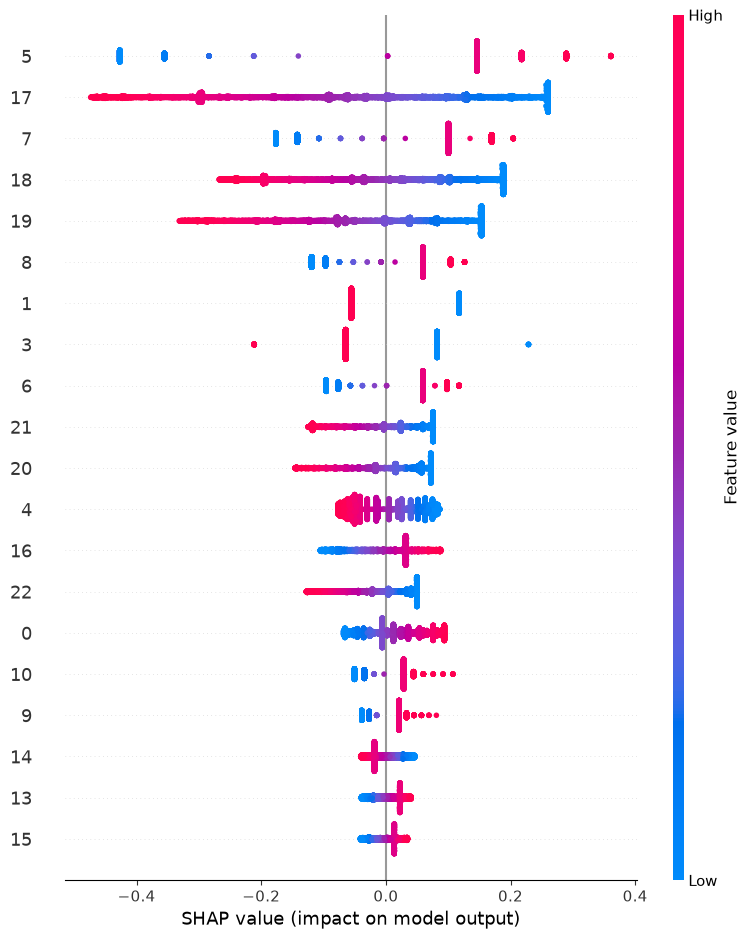

<Figure size 640x480 with 0 Axes>

In [22]:
shap.summary_plot(
    shap_values,
    X_test
)
plt.savefig("../reports/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

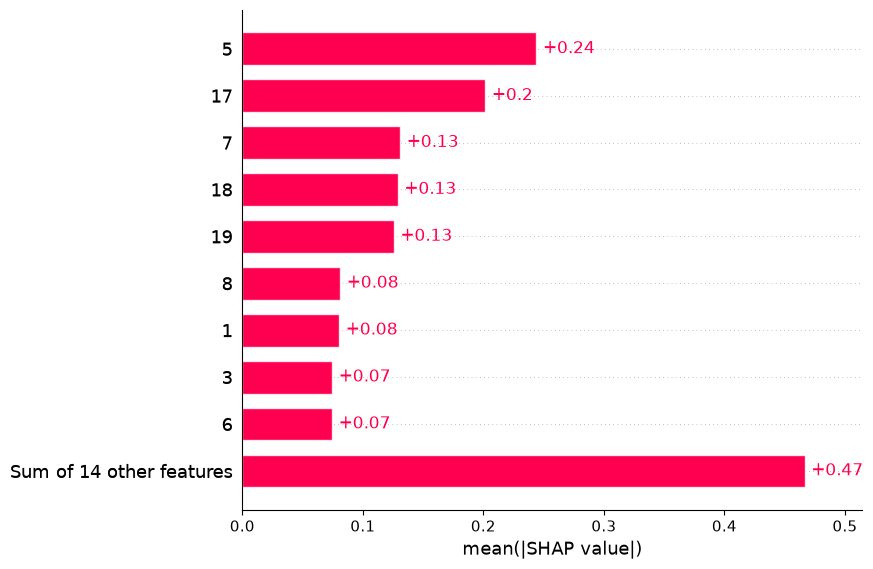

<Figure size 640x480 with 0 Axes>

In [23]:
#Bar plot
shap.plots.bar(shap_values)
plt.savefig("../reports/shape_bar.png", dpi=300, bbox_inches="tight")
plt.show()


In [26]:
# Specific to one customer

customer_index = 25
shap_values[customer_index]

.values =
array([ 0.05195363,  0.11771201, -0.00576884,  0.08214651, -0.02986561,
        0.14614434,  0.05930422,  0.10044445,  0.05933217,  0.02118859,
       -0.05035727, -0.00125259, -0.00030194, -0.00078382, -0.03962591,
       -0.01325111,  0.07898042,  0.18368327,  0.18176559, -0.01253724,
       -0.11170213, -0.04210761, -0.05698671])

.base_values =
np.float64(-1.397177099038397)

.data =
array([ 0.77467701, -1.23432296,  0.18582826, -1.05729503,  0.43884413,
        0.49606407,  0.57733641,  0.59251302,  0.61324361,  0.62599566,
       -1.51854758,  0.11549695,  0.01480137, -0.15308015,  1.64123496,
       -0.57932337,  1.51706949, -0.94103032, -1.20730993, -0.08613533,
        1.64384658,  0.65515833,  0.90738669])

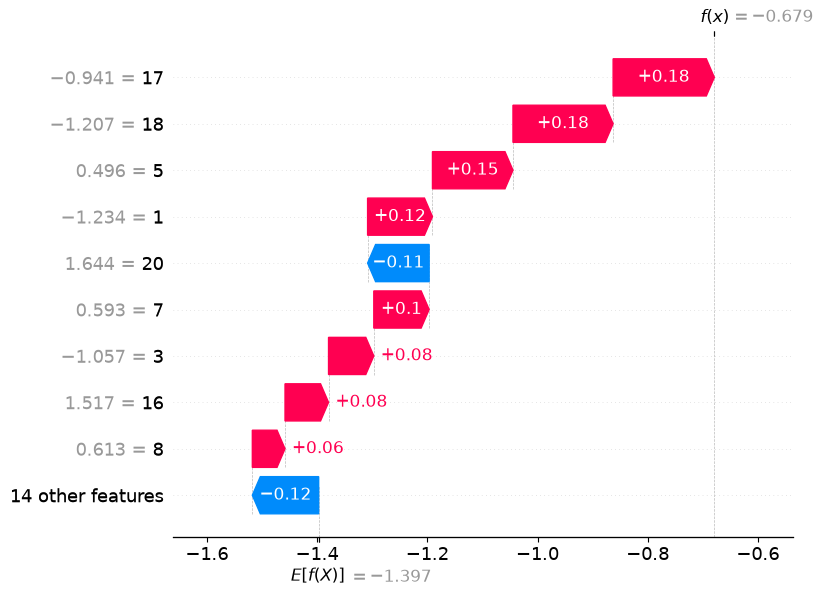

<Figure size 640x480 with 0 Axes>

In [27]:
shap.plots.waterfall(shap_values[25])
plt.savefig("../reports/shape_water.png", dpi=300, bbox_inches="tight")
plt.show()

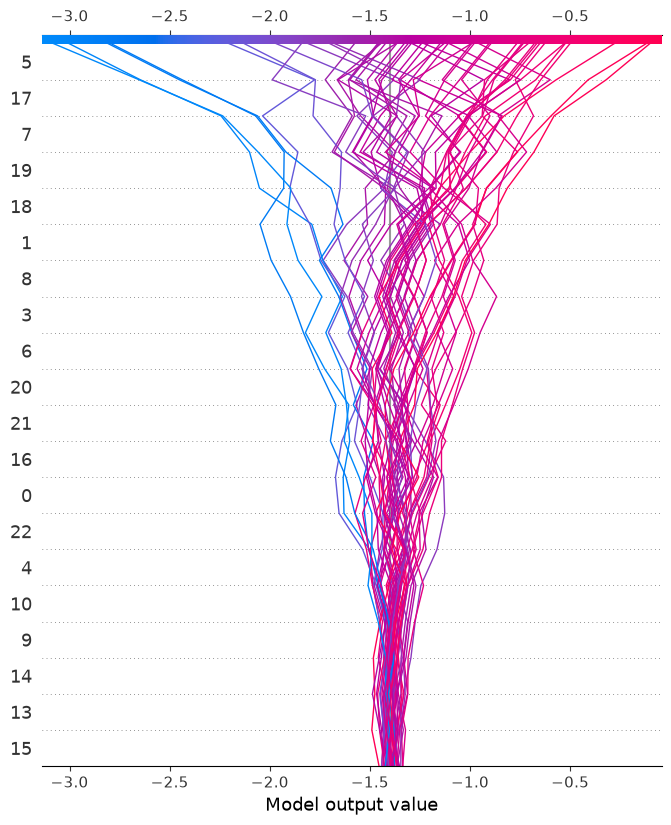

<Figure size 640x480 with 0 Axes>

In [29]:
# Desision plot 
shap.decision_plot(
    explainer.expected_value,
    shap_values.values[:50],
    X_test.iloc[:50]
)
plt.savefig("../reports/shape_Decision.png", dpi=300, bbox_inches="tight")
plt.show()